# Diabetes Prediction - Classification Pipeline

This notebook performs exploratory data analysis (EDA) on a diabetes prediction dataset and then builds preprocessing pipelines, trains classification models, evaluates their performance, and serializes the best model for deployment.

The dataset contains 100,000 medical records with demographic information, medical history, and clinical measurements. The objective is to predict whether a patient has diabetes based on these features, making this a binary classification problem.

The dataset was obtained from Kaggle:
https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

In [2]:
data = pd.read_csv('../data/diabetes_prediction_dataset.csv')
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


## Basic information and statistics
The .info() method provides a quick overview of the dataset, including the number of non-null values and the data type of each column.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


The .describe() method can also be used to obtain summary statistics for the numerical columns in the dataset. The output is transposed to make it easier to read.

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


### Column Descriptions

In total we have 9 columns:
- **gender**: Gender of the patient (Female, Male, Other)
- **age**: Age of the patient in years (ranging from 0.08 to 80)
- **hypertension**: Whether the patient has hypertension (0 = No, 1 = Yes)
- **heart_disease**: Whether the patient has heart disease (0 = No, 1 = Yes)
- **smoking_history**: Smoking status of the patient (never, No Info, current, former, ever, not current)
- **bmi**: Body mass index (weight in kg / height in m²)
- **HbA1c_level**: Hemoglobin A1c level, a measure of average blood sugar over the last 2-3 months
- **blood_glucose_level**: Blood glucose level at the time of measurement (mg/dL)
- **diabetes**: Target variable (0 = No diabetes, 1 = Diabetes)

The dataset includes both numerical and categorical features. `gender` and `smoking_history` are categorical and will need to be encoded before training. `hypertension` and `heart_disease` are already binary (0/1).

#### Selected Features

For this analysis, all 8 features will be used to predict the target variable `diabetes`. The features cover demographics, medical history, and clinical measurements, so each one contributes relevant information for the prediction.

## Visualization of Numerical Features
The distributions of the numerical features are visualized using histograms with kernel density estimates (KDE).

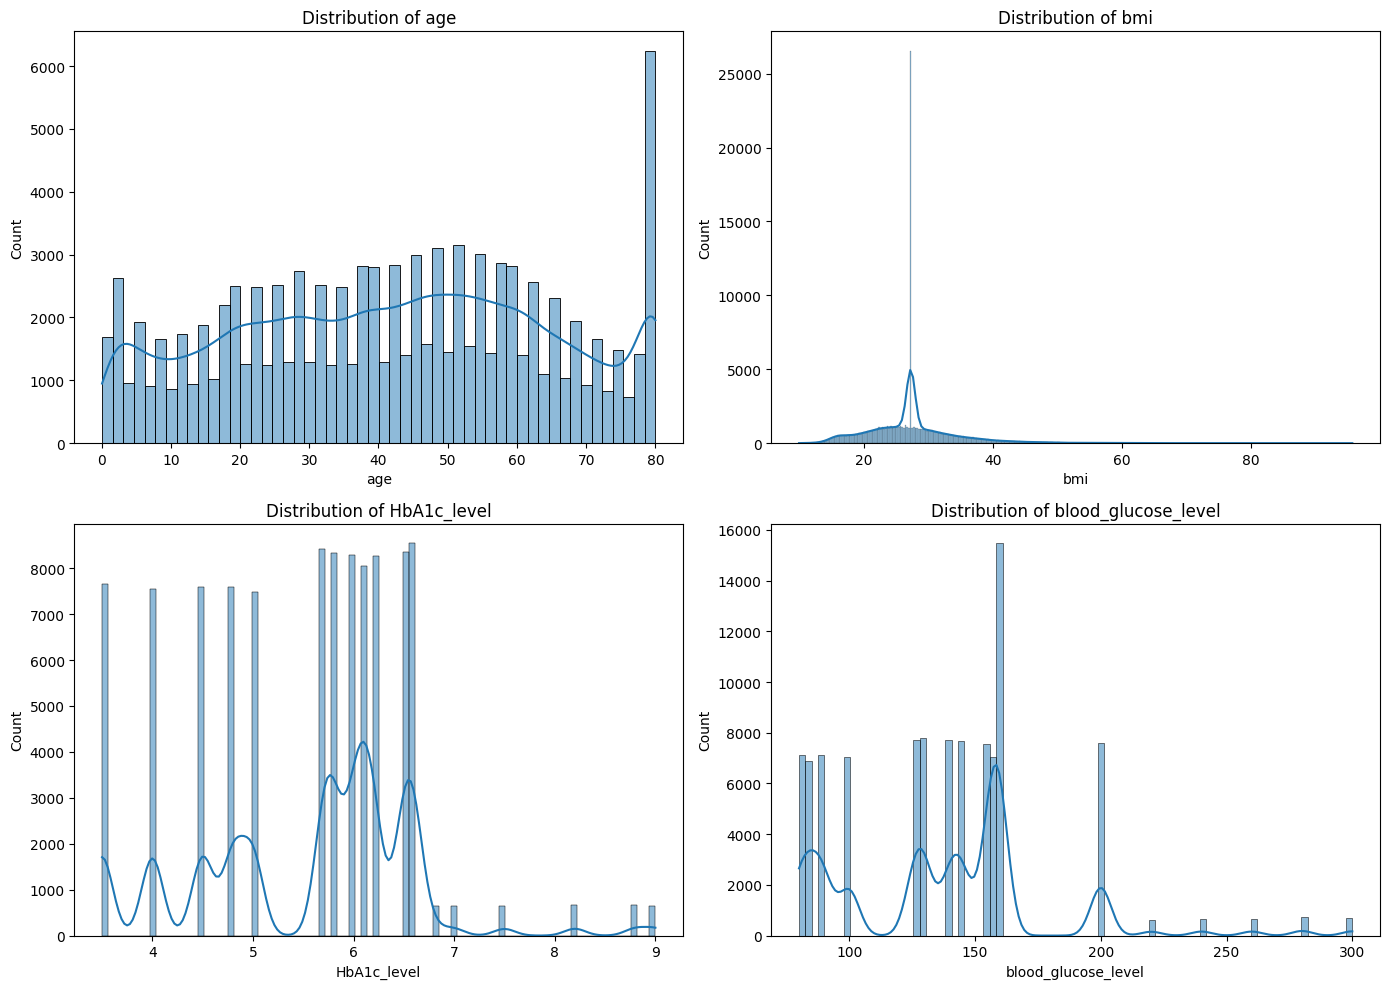

In [5]:
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axs.ravel(), numerical_features):
    sns.histplot(data[col].dropna(), kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

fig.tight_layout()

#### Observations on Numerical Features

- Age is spread across a wide range, with a concentration of younger patients.
- BMI follows an approximately normal distribution centered around 27, which is consistent with the general population.
- HbA1c_level shows several peaks, suggesting that the values may be grouped into clinical ranges.
- blood_glucose_level also has a multi-modal distribution, with a large concentration at lower values and a secondary peak at higher levels.

Since these features have different value ranges, scaling will be necessary so they are on a similar scale before training the model.

## Visualization of Categorical Features
The distributions of categorical and binary features are visualized using count plots.

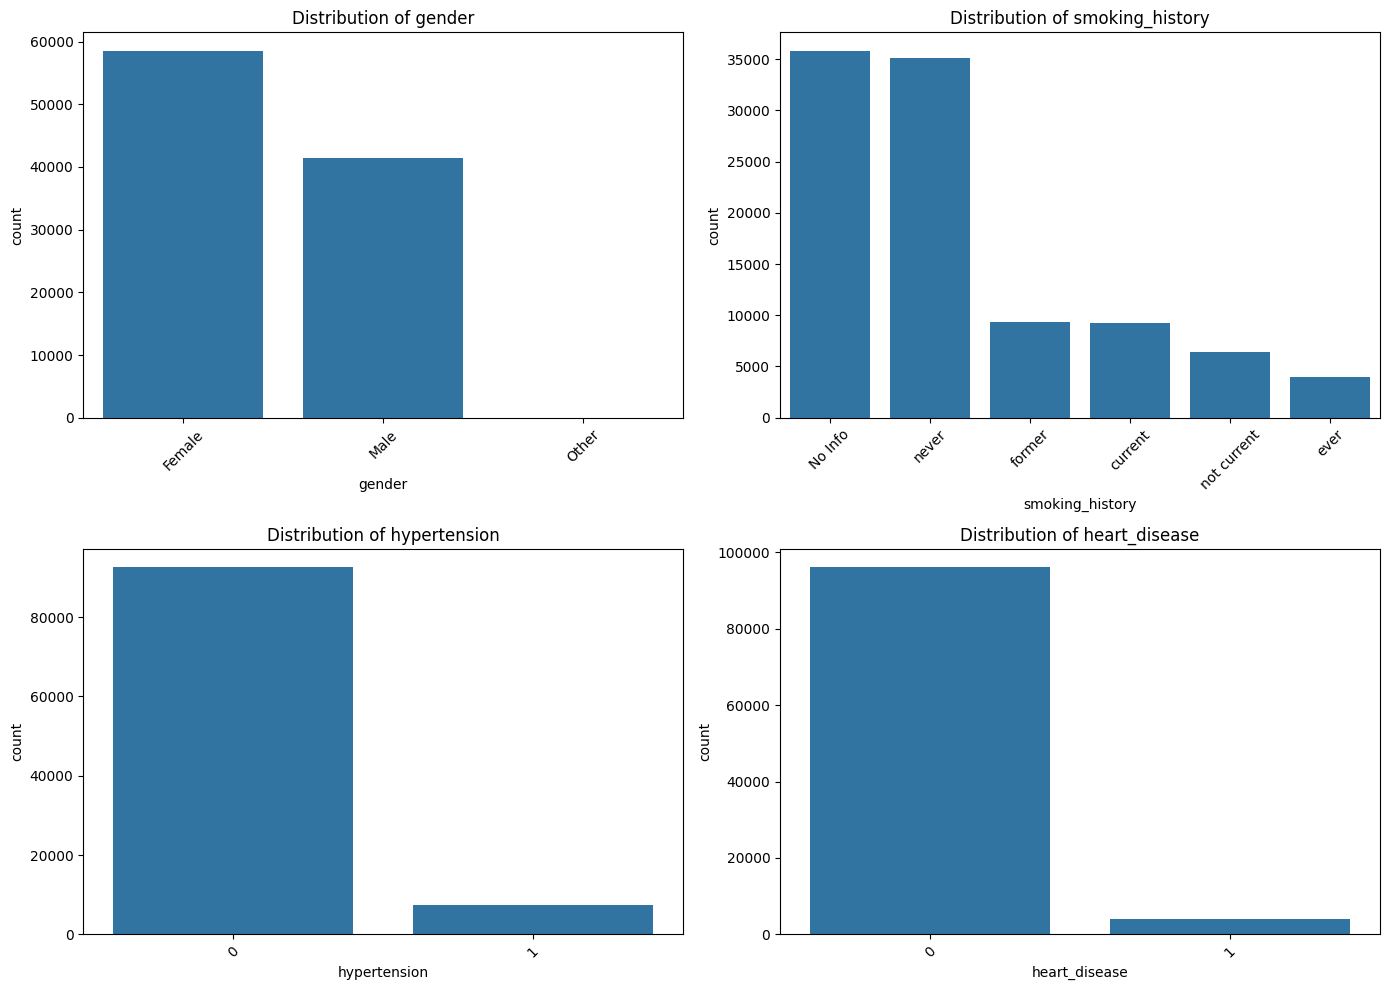

In [6]:
categorical_features = ['gender', 'smoking_history']
binary_features = ['hypertension', 'heart_disease']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axs.ravel(), categorical_features + binary_features):
    sns.countplot(data=data, x=col, ax=ax, order=data[col].value_counts().index)
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()

#### Observations on Categorical Features

- The dataset is approximately balanced between Female and Male patients, with very few \"Other\" entries.
- For smoking_history, the most common categories are "No Info" and "never". A significant portion of patients have no smoking information recorded.
- Hypertension and heart disease are relatively rare in this dataset, with most patients not having either condition.

## Target Label Distribution
The distribution of the target variable `diabetes` is visualized to understand the class balance in the dataset.

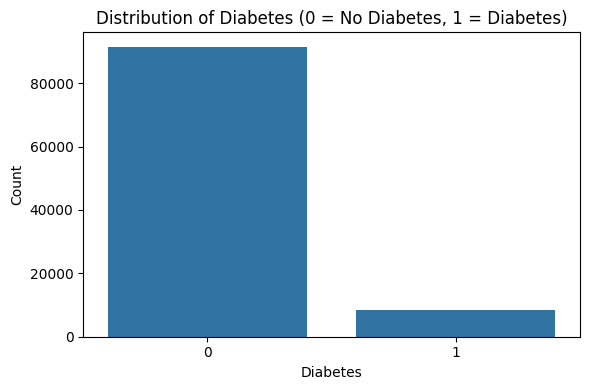

In [7]:
fig = plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='diabetes')
plt.title('Distribution of Diabetes (0 = No Diabetes, 1 = Diabetes)')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The dataset is imbalanced: most patients don't have diabetes. This should be considered when choosing evaluation metrics, so F1-score will be more appropriate than accuracy alone.

The distributions of the numerical features can be compared between patients with and without diabetes. Boxplots are used to clearly show these differences.

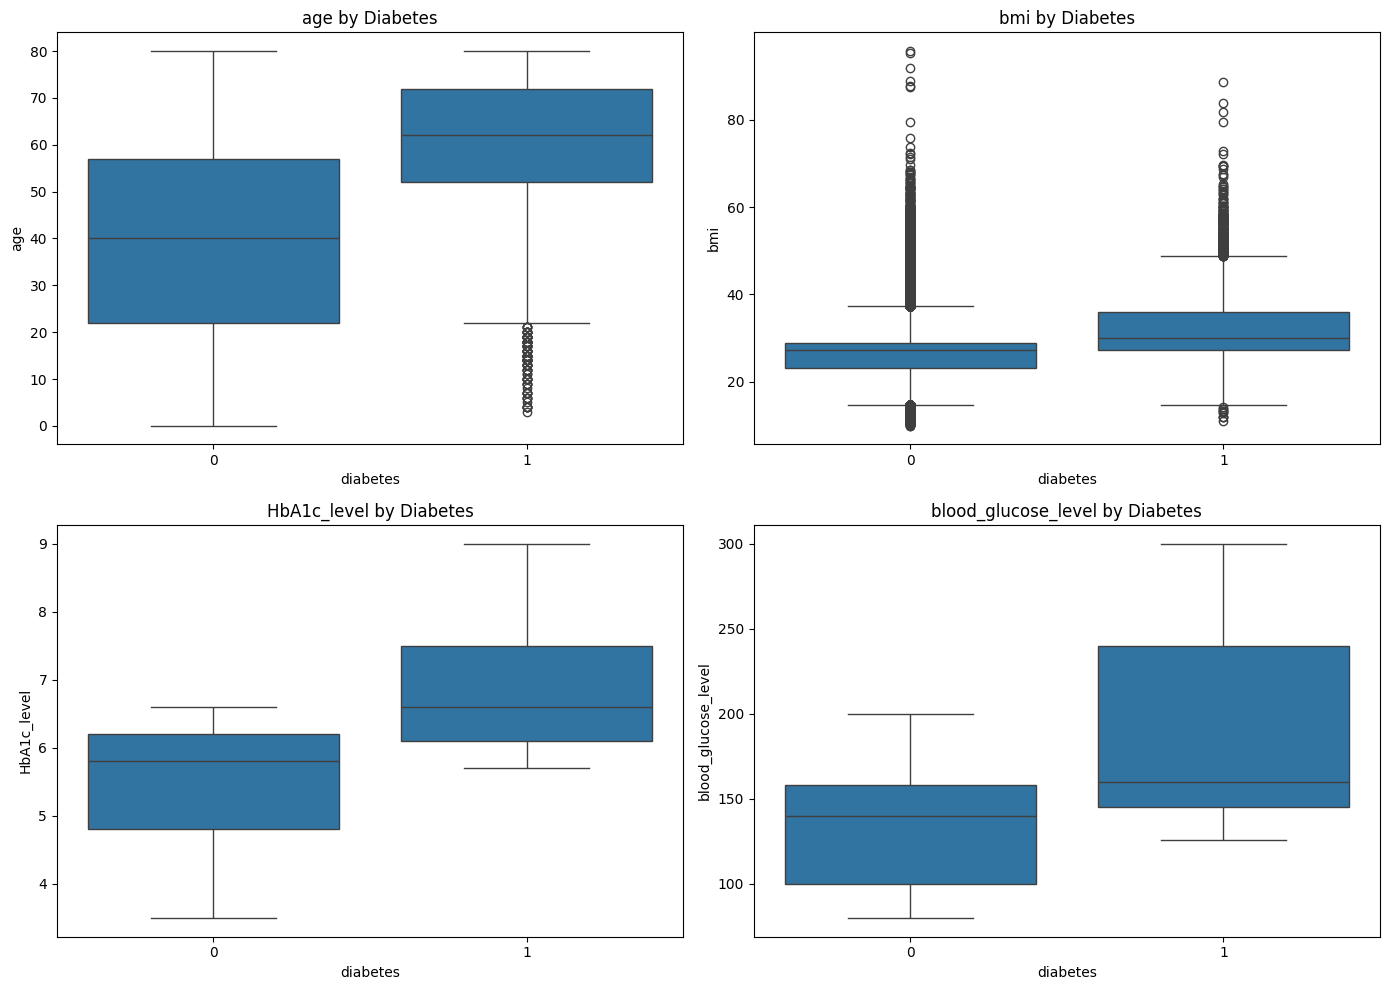

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axs.ravel(), numerical_features):
    sns.boxplot(data=data, x='diabetes', y=col, ax=ax)
    ax.set_title(f'{col} by Diabetes')

fig.tight_layout()

### Observations
- Patients with diabetes tend to have higher HbA1c_level and blood_glucose_level, which makes clinical sense.
- BMI is also higher in the diabetes group on average.
- Age shows a clear difference, with diabetic patients being older in general.
- These patterns are consistent with known risk factors for diabetes.

For categorical and binary features, countplots can be created with diabetes as the hue to show how the counts are distributed within each category.

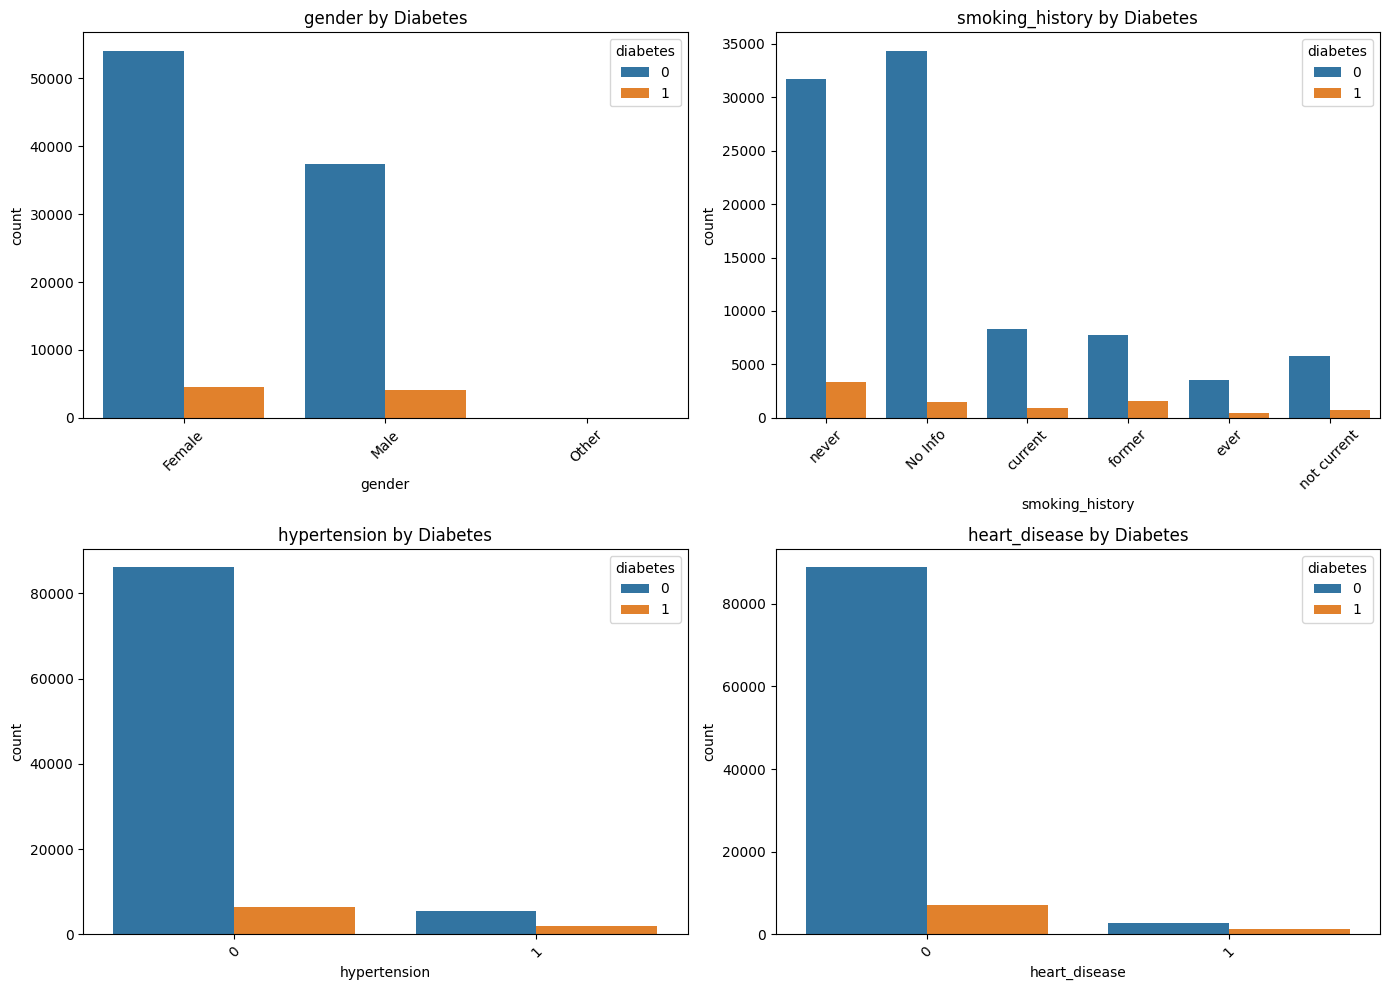

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axs.ravel(), categorical_features + binary_features):
    sns.countplot(data=data, x=col, hue='diabetes', ax=ax)
    ax.set_title(f'{col} by Diabetes')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()

### Observations
- Gender: The distribution between Male and Female is similar in both groups, so gender alone does not seem to be a strong differentiator.
- Smoking history: The "never" and "No Info" categories dominate in both groups. Patients with a "current" or "former" smoking history appear slightly more in the diabetes group.
- Hypertension: Patients with hypertension (1) show a higher proportion of diabetes compared to those without it.
- Heart disease: Similarly, patients with heart disease (1) have a noticeably higher rate of diabetes than those without.

## Correlation Matrix
A correlation matrix is used to quantify the relationships between the numerical features and the target variable.

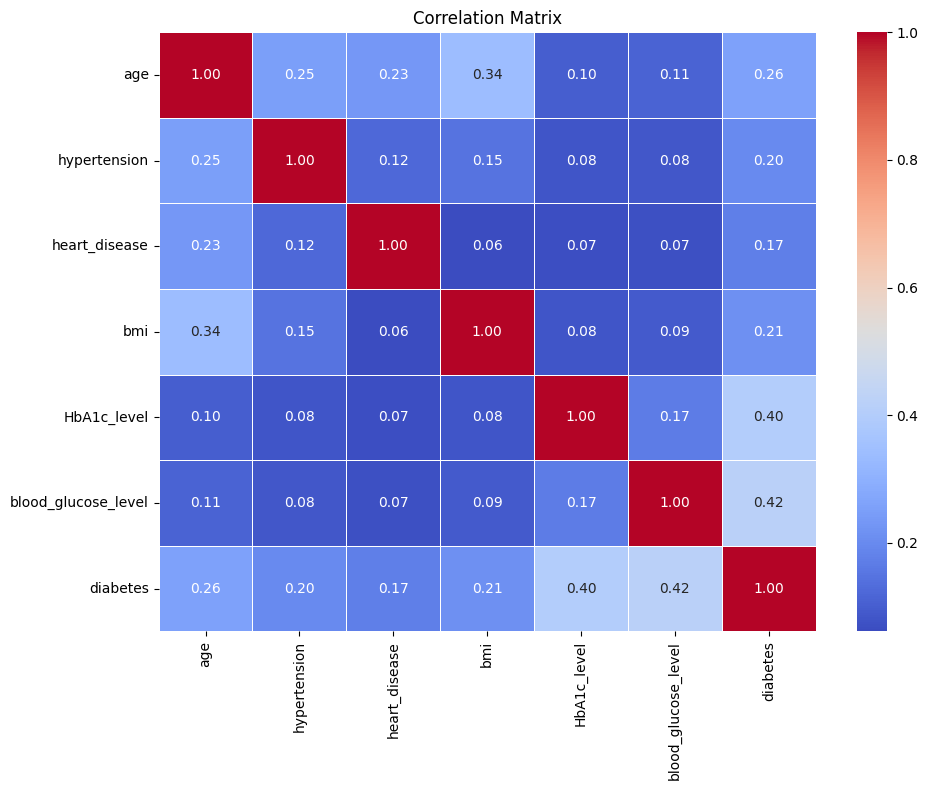

In [10]:
corr_matrix = data.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()

### Observations
The features that show the strongest correlation with diabetes are blood_glucose_level (0.42) and HbA1c_level (0.41), followed by age (0.26), BMI (0.21), and hypertension (0.20). There is also a notable correlation between age and BMI (0.34). These results are consistent with what was observed in the earlier visualizations.

## Missing and Duplicate Values
Before moving forward, the dataset is checked for missing values and duplicate rows.

In [11]:
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Total missing values: 0


In [12]:
#check for duplicates
duplicates = data.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

#remove duplicates if any
if duplicates > 0:
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Dataset size after removing duplicates: {len(data)}")

Duplicate rows: 3854
Dataset size after removing duplicates: 96146


### Observations
The dataset does not have any missing values, so no imputation is needed. However, 3,854 duplicate rows were found and removed, bringing the dataset down to 96,146 records. This cleanup ensures the model is not biased by repeated samples.

## Preprocessing Pipeline
Now that the dataset has been explored, a preprocessing pipeline can be put together. Based on the EDA, the features are split into three groups that need different treatment:

- **Numerical features** (age, bmi, HbA1c_level, blood_glucose_level): scaled using StandardScaler to normalize their ranges.
- **Binary features** (hypertension, heart_disease): already encoded as 0/1, so they are passed through without transformation.
- **Categorical features** (gender, smoking_history): encoded using OneHotEncoder to convert them into numerical columns.

`ColumnTransformer` is used to apply these different transformations to specific columns in an organized way.

In [13]:
binary_features = ['hypertension', 'heart_disease']

preprocessing = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_features),
        ('binary', 'passthrough', binary_features),
        ('categorical', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
    ],
    verbose_feature_names_out=False
)

## Train-Test Split
The feature matrix and target vector are defined, and the dataset is split into training and testing sets. An 80–20 split is used, with stratification to preserve the class distribution in both sets.

In [14]:
feature_columns = numerical_features + binary_features + categorical_features
x = data[feature_columns]
y = data['diabetes']

In [15]:
# stratify=y ensures class distribution is preserved in both sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

The class distribution in both sets can be checked to confirm that the proportions were preserved correctly.

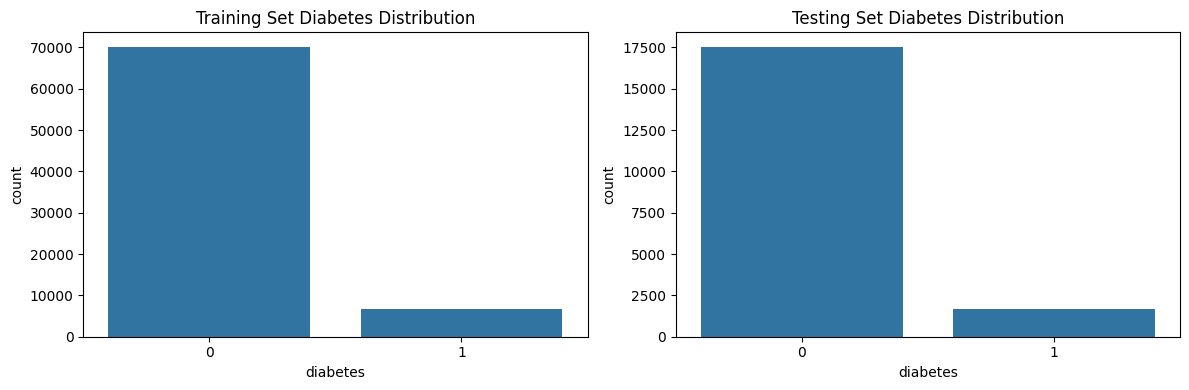

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title('Training Set Diabetes Distribution')
sns.countplot(x=y_test, ax=axs[1])
axs[1].set_title('Testing Set Diabetes Distribution')
fig.tight_layout()

## Applying the Preprocessing Pipeline
`fit_transform` is applied to the training data, while `transform` is used on the test data. It's important not to call `fit` or `fit_transform` on the test set, since that would allow information from the test data to influence the model during training.

In [17]:
x_train_processed = preprocessing.fit_transform(x_train)
x_train_processed

array([[ 1.44163858e-01, -5.09642732e-01,  1.58029614e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 9.89825469e-01,  8.45955712e-01, -1.42717889e+00, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.44163858e-01,  9.26550944e-04,  9.97257647e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-2.56412694e-01,  9.26550944e-04,  9.97257647e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 7.67282940e-01,  1.56075271e+00,  6.24267410e-01, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-7.90514764e-01,  9.26550944e-04,  6.24267410e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(76916, 13))

In [18]:
x_test_processed = preprocessing.transform(x_test)
x_test_processed

array([[ 0.41121489,  1.39944241,  0.99725765, ...,  0.        ,
         0.        ,  0.        ],
       [-1.32461683, -0.74346866, -0.9609411 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.81179145,  1.02502494,  0.62426741, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.01063834, -0.43120745, -0.9609411 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.58924892,  0.27323017,  0.15802961, ...,  0.        ,
         1.        ,  0.        ],
       [-1.23559982, -0.16186366, -1.89341669, ...,  0.        ,
         1.        ,  0.        ]], shape=(19230, 13))

## Model Training and Evaluation

### Defining objective metrics
For this classification task, the main evaluation metric will be the **F1-score**.

This dataset is imbalanced, with more non-diabetic patients than diabetic ones. Because of that, accuracy alone would not be a good metric, a model could simply predict the majority class and still get a high accuracy score.

In this medical context, both types of errors matter. A false negative (predicting no diabetes when the patient actually has it) could delay treatment, while a false positive (predicting diabetes when the patient doesn't) could lead to unnecessary procedures. The F1-score combines precision and recall into a single metric, balancing both aspects.

F1-score is used as the scoring metric during the GridSearchCV optimization process.

In [19]:
def evaluate_model(model, x_train, y_train, x_test, y_test):
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    return {
        'Train Accuracy': round(accuracy_score(y_train, y_train_pred), 4),
        'Test Accuracy': round(accuracy_score(y_test, y_test_pred), 4),
        'Train F1': round(f1_score(y_train, y_train_pred), 4),
        'Test F1': round(f1_score(y_test, y_test_pred), 4),
        'Train Precision': round(precision_score(y_train, y_train_pred), 4),
        'Test Precision': round(precision_score(y_test, y_test_pred), 4),
        'Train Recall': round(recall_score(y_train, y_train_pred), 4),
        'Test Recall': round(recall_score(y_test, y_test_pred), 4),
    }

### Model 1 - Logistic Regression

In [20]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(x_train_processed, y_train)

print(f"Best parameters: {grid_search_lr.best_params_}")
print(f"Best CV F1-score: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'C': 1, 'max_iter': 1000, 'solver': 'liblinear'}
Best CV F1-score: 0.7286


### Model 2 - Random Forest

In [21]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(x_train_processed, y_train)

print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best CV F1-score: {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1-score: 0.8024


### Model 3 - Gradient Boosting

In [22]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_gb.fit(x_train_processed, y_train)

print(f"Best parameters: {grid_search_gb.best_params_}")
print(f"Best CV F1-score: {grid_search_gb.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV F1-score: 0.8043


### Comparing Model Performance

The three best models are evaluated on the test set. Training set metrics are also included to identify overfitting or underfitting.

In [23]:
models = {
    'Logistic Regression': grid_search_lr,
    'Random Forest': grid_search_rf,
    'Gradient Boosting': grid_search_gb
}

results = []
for name, gs in models.items():
    model = gs.best_estimator_
    metrics = evaluate_model(model, x_train_processed, y_train, x_test_processed, y_test)
    metrics['Model'] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall
Model,,,,,,,,
Logistic Regression,0.9587,0.9596,0.7295,0.7362,0.8639,0.8692,0.6313,0.6386
Random Forest,0.9759,0.9714,0.8421,0.8082,0.9990,0.9889,0.7278,0.6834
Gradient Boosting,0.9712,0.9719,0.8073,0.8122,0.9862,0.9873,0.6833,0.6899


### Overfitting/Underfitting Analysis

To detect overfitting, training and test metrics are compared:
- If Train F1 is much higher than Test F1, the model is likely overfitting.
- If both scores are low, the model is likely underfitting.
- If both scores are similar and moderately high, the model demonstrates good generalization.

Looking at the results:

- **Logistic Regression** has very consistent scores between training and test sets, but both F1-scores are lower compared to the other models. The model is simple and stable, but doesn't capture the patterns as well.
- **Random Forest** achieves the highest training F1 (0.8421) and near-perfect training precision (0.9990), but its test F1 drops to 0.8082. There is some overfitting, though not as severe as with smaller datasets.
- **Gradient Boosting** shows the best generalization, with training and test metrics very close to each other. Its test F1 (0.8122) is the highest among all three models, and the gap between train and test scores is small.

### Best Model Selection
Based on the analysis above, **Gradient Boosting** is selected as the best model. Although Random Forest has a higher training F1, the gap between its training and test scores indicates some overfitting. Gradient Boosting achieves the best test F1-score (0.8122) and test accuracy (97.19%), with training and test metrics very close to each other, showing the best generalization to unseen data.

In [24]:
best_model_name = results_df['Test F1'].idxmax()
best_gs = models[best_model_name]
best_model = best_gs.best_estimator_

print(f"Best model: {best_model_name}")
print(f"Best hyperparameters: {best_gs.best_params_}")
print(f"F1-score on test: {results_df.loc[best_model_name, 'Test F1']:.4f}")
print(f"F1-score on train: {results_df.loc[best_model_name, 'Train F1']:.4f}")

Best model: Gradient Boosting
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
F1-score on test: 0.8122
F1-score on train: 0.8073


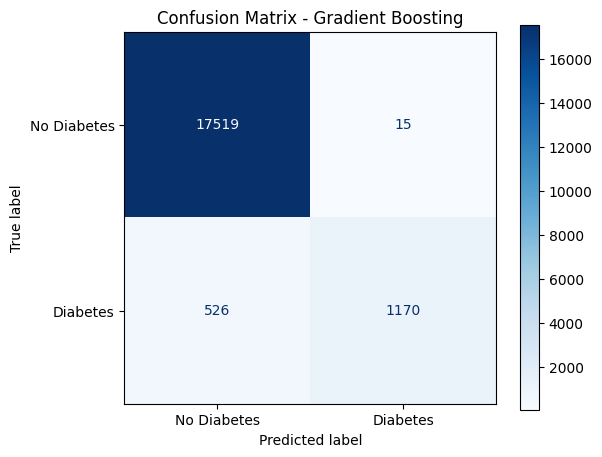

In [25]:
y_test_pred = best_model.predict(x_test_processed)

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

#### Observations
The model correctly identified 17,519 out of 17,534 non-diabetic patients, with only 15 being misclassified as diabetic (false positives). For the diabetic group, 1,170 out of 1,696 were correctly detected, while the remaining 526 were missed (false negatives). The model has very high precision for diabetes predictions, but its recall for the diabetic class could be improved to catch more actual cases.

In [26]:
print(f"Classification Report - {best_model_name}")
print("-" * 60)
print(classification_report(y_test, y_test_pred, target_names=['No Diabetes', 'Diabetes']))

Classification Report - Gradient Boosting
------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     17534
    Diabetes       0.99      0.69      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



#### Observations
The model achieves strong overall performance, with a precision of 0.99 and recall of 0.69 for the Diabetes class, resulting in an F1-score of 0.81. For the No Diabetes class, both precision and recall are above 0.97. The main area where the model could improve is in recall for diabetic patients, since about 31% of actual diabetes cases are being missed. In a medical context, this gap in recall is relevant because undetected cases could delay diagnosis and treatment.

## Model Serialization

To serialize the model, `joblib` can be used. The `dump` function serializes the complete pipeline (preprocessing + model) into a `.joblib` file, which can then be loaded elsewhere in Python using `joblib.load` to deserialize and run predictions.

In [27]:
import joblib

complete_pipeline = make_pipeline(preprocessing, best_model)
complete_pipeline.fit(x_train, y_train)

joblib.dump(complete_pipeline, '../models/diabetes_model.joblib')

['../models/diabetes_model.joblib']

## Final Remarks

In this notebook, a diabetes prediction dataset with 100,000 records was explored and used to build a classification pipeline. During the EDA phase, 3,854 duplicate rows were identified and removed. The dataset includes both numerical features (age, BMI, HbA1c level, blood glucose level) and categorical features (gender, smoking history), as well as binary indicators for hypertension and heart disease.

Three classification models were trained using GridSearchCV with 5-fold cross-validation: Logistic Regression, Random Forest, and Gradient Boosting. F1-score was chosen as the main optimization metric because the dataset is heavily imbalanced.

After comparing the results, Logistic Regression showed consistent but lower scores across both sets. Random Forest achieved high training metrics but showed some overfitting with a drop in test F1. Gradient Boosting achieved the best balance, with the highest test F1-score (0.8122) and test accuracy (97.19%), and very close train/test metrics, making it the most reliable option for generalization.

The confusion matrix and classification report showed that the model is very precise when predicting diabetes (0.99 precision), meaning almost all positive predictions are correct. However, its recall for the diabetic class (0.69) indicates that about 31% of actual diabetic patients are being missed. 

The best model was serialized using `joblib` along with the full preprocessing pipeline, ensuring that new data goes through the same transformations before making predictions. This serialized model is used in the web application to provide diabetes risk predictions based on clinical measurements.